In [65]:
from analysis import get_market_participants
from utils import get_market_df, TRADERS_IN_FINANCIAL_FUTURES_FUT, LEGUACY_FUT, DISAGGREGATED_FUT, print_json, plot_df_chart
import pandas as pd

In [66]:
MARKETS = [
    "USD INDEX",
    "BRITISH POUND",
    "CANADIAN DOLLAR",
    "SWISS FRANC",
    "BRITISH POUND",
    "JAPANESE YEN",
    "EURO FX",
    "AUSTRALIAN DOLLAR",
    "NZ DOLLAR",
]

PAIR = ("USD INDEX", "BRITISH POUND")

REPORT_TYPE = TRADERS_IN_FINANCIAL_FUTURES_FUT

In [67]:
participants = get_market_participants(get_market_df(cot_report_type=REPORT_TYPE, market=MARKETS[0], last_year=True, verbose=False))

list(participants.keys())

['dealer', 'asset_mgr', 'lev_money', 'other_rept', 'tot_rept', 'nonrept']

In [68]:
PARTICIPANT = "lev_money"

participant = participants[PARTICIPANT]

In [69]:
def pair_gap_df(pair, participant=participant, report_type=REPORT_TYPE):
    _df = pd.DataFrame()

    for market in pair:
        market_df = get_market_df(cot_report_type=report_type, market=market, verbose=False)
        _market_long = market_df[participant["long"]]
        _market_short = market_df[participant["short"]]
        _df[market] = 100 * (_market_long - _market_short) / (_market_long + _market_short)

    _df["XY(gap)"] = (_df[pair[0]] - _df[pair[1]]) / 2

    return _df

In [70]:
df = pair_gap_df(pair=PAIR, participant=participant, report_type=REPORT_TYPE)

df = df[["XY(gap)"]]

df

,XY(gap)
Date,
2006-06-13,-37.636213
2006-06-20,-42.031734
2006-06-27,-20.701989
2006-07-03,-19.003848
2006-07-11,-15.431184
...,...
2026-01-20,-30.039395
2026-01-27,-16.657450
2026-02-03,-14.509757


In [71]:
plot_df_chart(
    df,
    chart_title=f"GAP - ({PAIR[0]}/{PAIR[1]}) - {PARTICIPANT}",
)

## Forex matrix

In [72]:
metrics = {}

for market in MARKETS:
    _df = get_market_df(cot_report_type=REPORT_TYPE, market=market, last_year=True, verbose=False).iloc[[-1]]

    _long = _df[participant["long"]].values[0]
    _short = _df[participant["short"]].values[0]

    metrics[market] = 100 * (_long - _short)/(_long + _short)

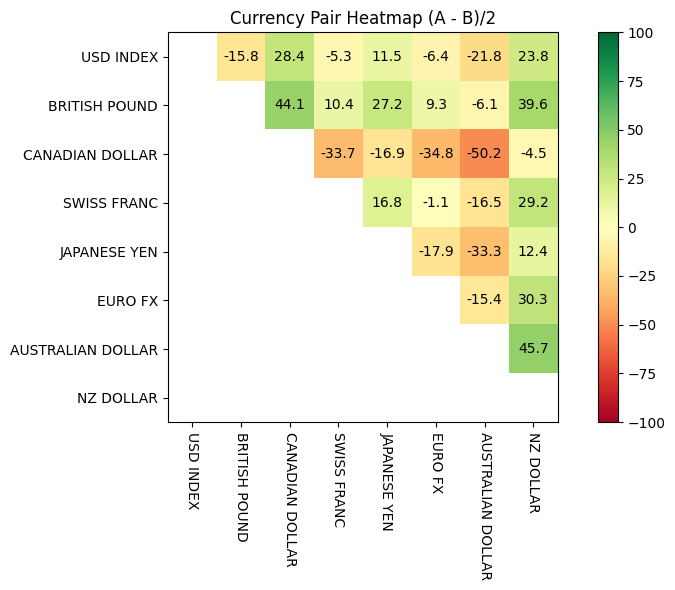

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

currencies = list(metrics.keys())
n = len(currencies)

matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        matrix[i, j] = (metrics[currencies[i]] - metrics[currencies[j]]) / 2

# mask = np.triu(np.ones_like(matrix, dtype=bool))
mask = np.tril(np.ones_like(matrix, dtype=bool))
masked_matrix = np.ma.masked_where(mask, matrix)

norm = TwoSlopeNorm(vmin=-100, vcenter=0, vmax=100)
# norm = TwoSlopeNorm(vmin=matrix.min(), vcenter=0, vmax=matrix.max())

plt.figure(figsize=(9, 6))
plt.imshow(masked_matrix, cmap="RdYlGn", norm=norm)
plt.colorbar()

plt.xticks(range(n), currencies, rotation=-90)
plt.yticks(range(n), currencies)

# Annotate only visible cells
for i in range(n):
    for j in range(n):
        if not mask[i, j]:
            plt.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center")

plt.title("Currency Pair Heatmap (A - B)/2")
plt.tight_layout()
plt.show()